In [1]:
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.imagenet_utils import preprocess_input

In [2]:
from tensorflow.keras import applications

In [4]:
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dropout, Dense

In [1]:
import numpy as np
import cv2

In [7]:
MODEL_PATH = "iamodels/diabetes_4.h5"

# Dimensiones
IMG_SIZE  = 512
HEIGHT = 320
WIDTH = 320

# Clases
labels = ['0', '1', '2', '3']

In [9]:
import tensorflow as tf

In [14]:
# Model
# Cargar el modelo deshabilitando la carga de los argumentos adicionales del optimizador
custom_objects = {'Optimizer': tf.optimizers.Adam}  # Ajusta el optimizador según el que hayas utilizado
new_model = tf.keras.models.load_model('diabetes_4.h5', custom_objects=custom_objects, compile=False)

# Recompilar el modelo después de cargarlo
new_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [15]:
def crop_image_from_gray(img,tol=7):
    if img.ndim ==2:
        mask = img>tol
        return img[np.ix_(mask.any(1),mask.any(0))]
    elif img.ndim==3:
        gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        mask = gray_img>tol
        
        check_shape = img[:,:,0][np.ix_(mask.any(1),mask.any(0))].shape[0]
        if (check_shape == 0): # image is too dark so that we crop out everything,
            return img # return original image
        else:
            img1=img[:,:,0][np.ix_(mask.any(1),mask.any(0))]
            img2=img[:,:,1][np.ix_(mask.any(1),mask.any(0))]
            img3=img[:,:,2][np.ix_(mask.any(1),mask.any(0))]
    #         print(img1.shape,img2.shape,img3.shape)
            img = np.stack([img1,img2,img3],axis=-1)
    #         print(img.shape)
        return img

def circle_crop(img, sigmaX = 30):   
    """
    Create circular crop around image centre    
    """    
    img = crop_image_from_gray(img)    
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    height, width, depth = img.shape    
    
    x = int(width/2)
    y = int(height/2)
    r = np.amin((x,y))
    
    circle_img = np.zeros((height, width), np.uint8)
    cv2.circle(circle_img, (x,y), int(r), 1, thickness=-1)
    img = cv2.bitwise_and(img, img, mask=circle_img)
    img = crop_image_from_gray(img)
    img=cv2.addWeighted(img,4, cv2.GaussianBlur( img , (0,0) , sigmaX) ,-4 ,128)
    return img 

def preprocess_image(filepath):
    img = cv2.imread(filepath)
    img = circle_crop(img) 
    return cv2.resize(img, (HEIGHT,WIDTH))

In [42]:
img_preprocess = preprocess_image("./train_images/00a8624548a9.png")

In [43]:
img = cv2.imread("./train_images/00a8624548a9.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (HEIGHT,WIDTH))

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["axes.grid"] = False

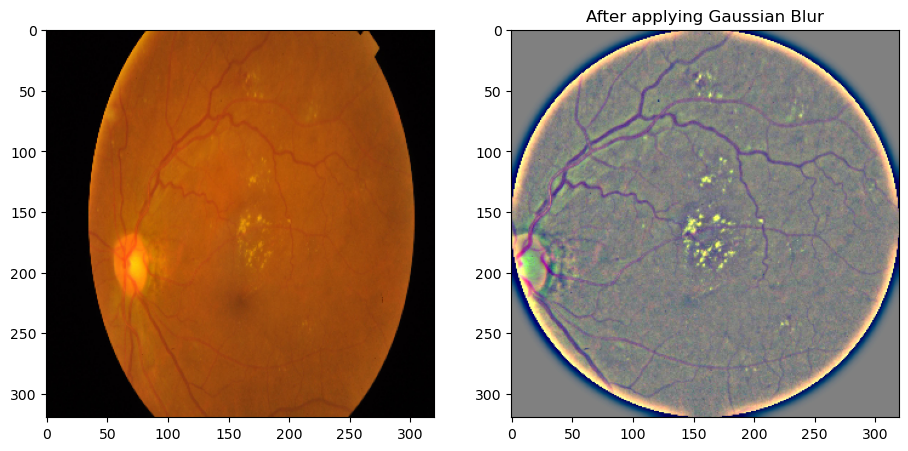

In [44]:
f, axarr = plt.subplots(1,2,figsize = (11,11))
axarr[0].imshow(img)
axarr[1].imshow(img_preprocess)
plt.title('After applying Gaussian Blur')
plt.show()

In [45]:
img_preprocess.shape

(320, 320, 3)

In [27]:
from tensorflow.keras.preprocessing.image import img_to_array

In [46]:
image_array = img_to_array(img_preprocess)
x = image_array.reshape((1,) + image_array.shape)  # Agregar dimensión del lote

In [47]:
pred = new_model.predict(x)

1/1 [==============================] - 0s 18ms/step


In [48]:
labels[np.argmax(pred)]

'0'

In [49]:
pred

array([[1., 0., 0., 0.]], dtype=float32)